# Which instrument, and which label? — a deflated grid search

Searches the front-end STIR complex for the best expression of the central-bank speaker
hawk/dove signal, across six currencies:

| dimension | values |
|---|---|
| **structure** | outrights `OUT_1..6`, calendar spreads `SPR_n_m`, butterflies `FLY_n_b_k`, packs `PACK_n` — built from the 1st…6th quarterly IMM contracts |
| **labelling** | `peer` (relative to committee), `percentile` (relative to own past), `absolute` (Fed ±10/±20), `researched` (hand-researched standing), `blended` (peer ∧ researched) |
| **timing** | entry T−120…−15m, exit T+60…+240m |

### The thing this notebook is really about

Ranking thousands of configurations by Sharpe **finds a high Sharpe whether or not any signal
exists**. With ~2,000 trials, the best of them will show an annualised Sharpe near 1 even when
every single one is noise. So the headline number here is not the top Sharpe — it is the
**Deflated Sharpe Ratio**, which asks: given that we searched this hard, what is the probability
this strategy's *true* Sharpe is above zero?

DSR uses the spread of Sharpes actually observed across the grid to calibrate what the search
could have produced by chance, and corrects for skew and kurtosis — which matter here, because an
event study is exactly the shape (rare large moves) that inflates a naive Sharpe.

A configuration is only interesting if **DSR > 0.95 with a meaningful trade count**.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, pickle
from pathlib import Path

REPO = r"C:\Users\chris\clee\ARBS-gcb"
HERE = Path(REPO) / "notebooks" / "backtests" / "intraday_fed_hawk_dove"
sys.path.insert(0, REPO); sys.path.insert(0, str(HERE))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns

plt.style.use("ggplot")
pylab.rcParams.update({"figure.figsize": (14, 6), "axes.titlesize": "large"})

import global_hawk_dove_common as G
import global_hawk_dove_grid as GRID
from global_hawk_dove_run import CACHE, BANKS

with open(CACHE / "grid_panel.pkl", "rb") as f:
    store = pickle.load(f)

MAX_RANK = 6
structures = GRID.build_structures(MAX_RANK)
print(f"{len(structures)} structures, {len(store)} labelling schemes")
for m, blob in store.items():
    tot = sum(len(v) for v in blob["metas"].values())
    print(f"  {m:12s} legs={list(blob['panels'])}  events={tot}")

C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\intraday_fed_hawk_dove\global_hawk_dove_common.py:47: LicenceNotice: 
Rateslib is source-available (not open-source) software distributed under a dual-licence model.
No commercial licence is registered for this installation. Use is therefore permitted for non-commercial purposes only (at-home or university based academic use).
Any use in commercial, professional, or for-profit environments, including evaluation or trial use, requires a valid commercial licence or an approved evaluation licence.
Certain features may require a registered commercial or evaluation licence in current or future versions.
For licensing information or to register a licence, please visit: https://rateslib.com/licence
  from rateslib.scheduling import next_imm


22 structures, 3 labelling schemes
  peer         legs=['FED', 'ECB', 'BOE', 'BOJ', 'BOC', 'SNB']  events=1119
  percentile   legs=['FED', 'ECB', 'BOE', 'BOJ', 'BOC', 'SNB']  events=1089
  absolute     legs=['FED', 'ECB', 'BOE', 'BOJ', 'BOC', 'SNB']  events=912


## 1. The grid

In [2]:
from global_hawk_dove_grid_run import CAUSAL_MODES, NONCAUSAL_MODES, ENTRY_MIN, EXIT_MIN

frames = []
for mode, blob in store.items():
    g = GRID.run_grid(blob["panels"], blob["metas"], structures, cost_bp=0.0)
    if g.empty:
        continue
    g["bucket_mode"] = mode
    g["causal"] = mode in CAUSAL_MODES
    frames.append(g)
allg = pd.concat(frames, ignore_index=True)

# The researched / blended labels were written in 2026 about trades from 2023-2026.
# They are not tradeable, so they are held out of the ranking and deflated on their
# own; mixing a fitted label into the same deflation as honest ones understates the
# hurdle for the honest ones.
grid = allg[allg["causal"]].reset_index(drop=True)
noncausal = allg[~allg["causal"]].reset_index(drop=True)
N_TRIALS = len(grid) * len(ENTRY_MIN) * len(EXIT_MIN)
grid = GRID.add_deflated(grid, n_trials=N_TRIALS)
show = ["structure", "kind", "bucket_mode", "trades", "total_bp", "avg_bp",
        "hit", "sharpe_ann", "t_stat", "dsr"]
print(f"configs scored: {len(grid)}   trials priced into the deflation: {N_TRIALS}")
print(f"selection hurdle SR* (per-trade): {grid['sr_star'].iloc[0]:.4f}")
display(grid[show].head(25).round(4))

configs scored: 66   trials priced into the deflation: 1056
selection hurdle SR* (per-trade): 0.0540


,structure,kind,bucket_mode,trades,total_bp,avg_bp,hit,sharpe_ann,t_stat,dsr
45,OUT_2,outright,absolute,865,107.1823,0.1239,0.4647,0.7411,1.3366,0.3978
22,OUT_1,outright,percentile,1024,74.3022,0.0726,0.3936,0.7299,1.3164,0.3304
0,OUT_1,outright,peer,1052,70.5649,0.0671,0.4068,0.7107,1.2818,0.3089
48,OUT_5,outright,absolute,865,154.2335,0.1783,0.4786,0.6999,1.2623,0.3712
63,PACK_1,pack,absolute,865,104.8161,0.1212,0.5145,0.6965,1.2561,0.3670
64,PACK_2,pack,absolute,865,127.7688,0.1477,0.5168,0.6915,1.2470,0.3647
44,OUT_1,outright,absolute,865,62.4228,0.0722,0.4208,0.6847,1.2349,0.3529
65,PACK_3,pack,absolute,865,138.3229,0.1599,0.5272,0.6737,1.2150,0.3531
49,OUT_6,outright,absolute,865,149.3987,0.1727,0.4844,0.6722,1.2123,0.3527
62,FLY_4_5_6,fly,absolute,865,6.5137,0.0075,0.4393,0.6562,1.1835,0.3430


## 2. The honest answer

The left panel is what a naive search reports; the right is what survives pricing the search.

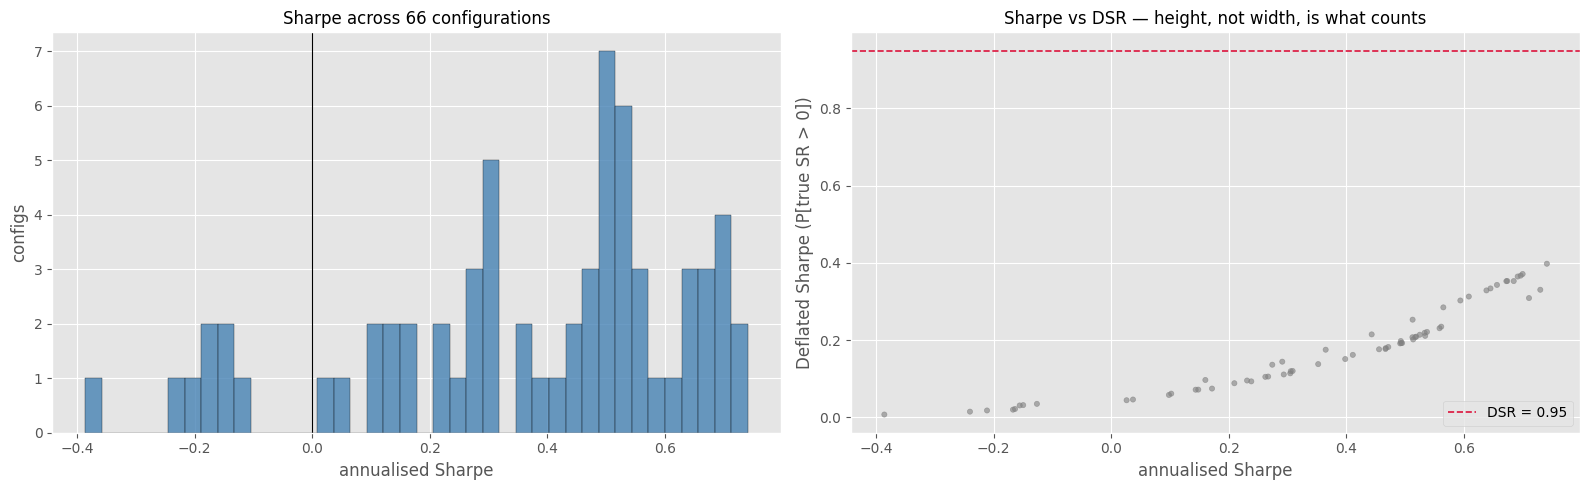

configs with DSR > 0.95 and >= 50 trades: 0 / 66


'NONE'

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.hist(grid["sharpe_ann"], bins=40, color="steelblue", alpha=.8, edgecolor="k", lw=.3)
ax.axvline(0, color="k", lw=.8)
ax.set_xlabel("annualised Sharpe"); ax.set_ylabel("configs")
ax.set_title(f"Sharpe across {len(grid)} configurations")

ax = axes[1]
ax.scatter(grid["sharpe_ann"], grid["dsr"], s=14, alpha=.6,
           c=np.where(grid["dsr"] > 0.95, "seagreen", "grey"))
ax.axhline(0.95, color="crimson", ls="--", lw=1.2, label="DSR = 0.95")
ax.set_xlabel("annualised Sharpe"); ax.set_ylabel("Deflated Sharpe (P[true SR > 0])")
ax.set_title("Sharpe vs DSR — height, not width, is what counts")
ax.legend()
plt.tight_layout(); plt.show()

alive = grid[(grid["dsr"] > 0.95) & (grid["trades"] >= 50)]
print(f"configs with DSR > 0.95 and >= 50 trades: {len(alive)} / {len(grid)}")
display(alive[show].round(4).head(20) if len(alive) else "NONE")

if len(noncausal):
    nc = GRID.add_deflated(noncausal, n_trials=len(noncausal) * len(ENTRY_MIN) * len(EXIT_MIN))
    print(chr(10) + "NON-CAUSAL UPPER BOUND - researched / blended labels.")
    print("Written in 2026 about these very trades, so NOT tradeable. Shown only to bound")
    print("what perfect knowledge of who was a hawk would have been worth:")
    display(nc.sort_values("sharpe_ann", ascending=False)[
        ["structure", "bucket_mode", "trades", "avg_bp", "sharpe_ann", "t_stat"]].head(8).round(4))

## 3. Which structure family, and which label?

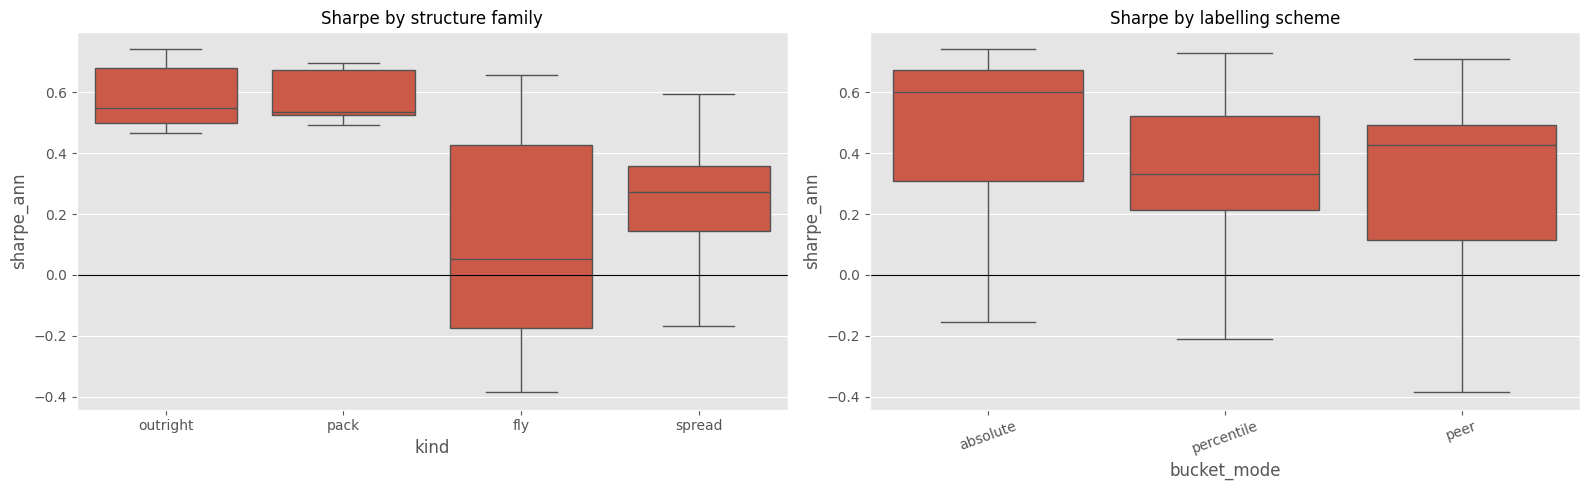

by structure family:


sharpe_ann                  avg_bp  trades     dsr
              count  median     max  median  median     max
kind                                                       
fly              12  0.0523  0.6562  0.0006  1024.0  0.3430
outright         18  0.5493  0.7411  0.1039  1024.0  0.3978
pack              9  0.5341  0.6965  0.1012  1024.0  0.3670
spread           27  0.2740  0.5939  0.0095  1024.0  0.3026

by labelling scheme:


sharpe_ann                  avg_bp  trades     dsr
                 count  median     max  median  median     max
bucket_mode                                                   
absolute            22  0.6011  0.7411  0.0238   865.0  0.3978
peer                22  0.4268  0.7107  0.0134  1052.0  0.3089
percentile          22  0.3303  0.7299  0.0116  1024.0  0.3304

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=grid, x="kind", y="sharpe_ann", ax=axes[0])
axes[0].axhline(0, color="k", lw=.8); axes[0].set_title("Sharpe by structure family")
sns.boxplot(data=grid, x="bucket_mode", y="sharpe_ann", ax=axes[1])
axes[1].axhline(0, color="k", lw=.8); axes[1].set_title("Sharpe by labelling scheme")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

print("by structure family:")
display(grid.groupby("kind")[["sharpe_ann", "avg_bp", "trades", "dsr"]]
        .agg({"sharpe_ann": ["count", "median", "max"], "avg_bp": "median",
              "trades": "median", "dsr": "max"}).round(4))
print("by labelling scheme:")
display(grid.groupby("bucket_mode")[["sharpe_ann", "avg_bp", "trades", "dsr"]]
        .agg({"sharpe_ann": ["count", "median", "max"], "avg_bp": "median",
              "trades": "median", "dsr": "max"}).round(4))

### Structure vs contract rank

Outrights only, so the comparison is like-for-like: does the signal live at the very front of the
strip or further out? A monotone rise with rank is a warning sign, not a discovery — it usually
means duration beta rather than anything about the speech.

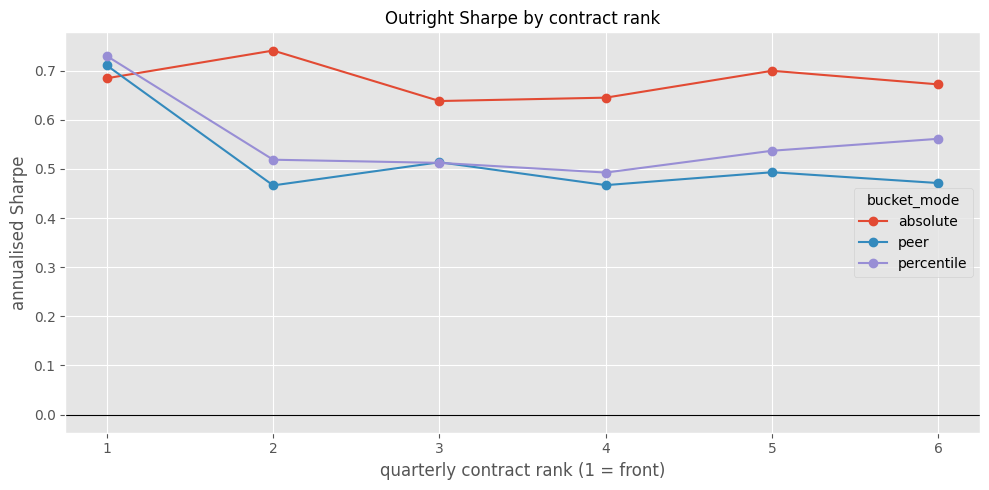

bucket_mode,absolute,peer,percentile
rank,,,
1,0.685,0.711,0.730
2,0.741,0.467,0.519
3,0.638,0.514,0.512
4,0.645,0.467,0.493
5,0.700,0.493,0.537
6,0.672,0.471,0.561


In [5]:
out = grid[grid.kind == "outright"].copy()
out["rank"] = out["structure"].str.split("_").str[1].astype(int)
piv = out.pivot_table(index="rank", columns="bucket_mode", values="sharpe_ann")
fig, ax = plt.subplots(figsize=(10, 5))
piv.plot(marker="o", ax=ax)
ax.axhline(0, color="k", lw=.8)
ax.set_xlabel("quarterly contract rank (1 = front)"); ax.set_ylabel("annualised Sharpe")
ax.set_title("Outright Sharpe by contract rank")
plt.tight_layout(); plt.show()
display(piv.round(3))

## 4. Cost sensitivity of the best configurations

config,OUT_1|absolute,OUT_1|peer,OUT_1|percentile,OUT_2|absolute,OUT_5|absolute,PACK_1|absolute,PACK_2|absolute,PACK_3|absolute
cost_bp,,,,,,,,
0.000,62.4,70.6,74.3,107.2,154.2,104.8,127.8,138.3
0.125,-45.7,-60.9,-53.7,-0.9,46.1,-3.3,19.6,30.2
0.250,-153.8,-192.4,-181.7,-109.1,-62.0,-111.4,-88.5,-77.9
0.500,-370.1,-455.4,-437.7,-325.3,-278.3,-327.7,-304.7,-294.2
1.000,-802.6,-981.4,-949.7,-757.8,-710.8,-760.2,-737.2,-726.7


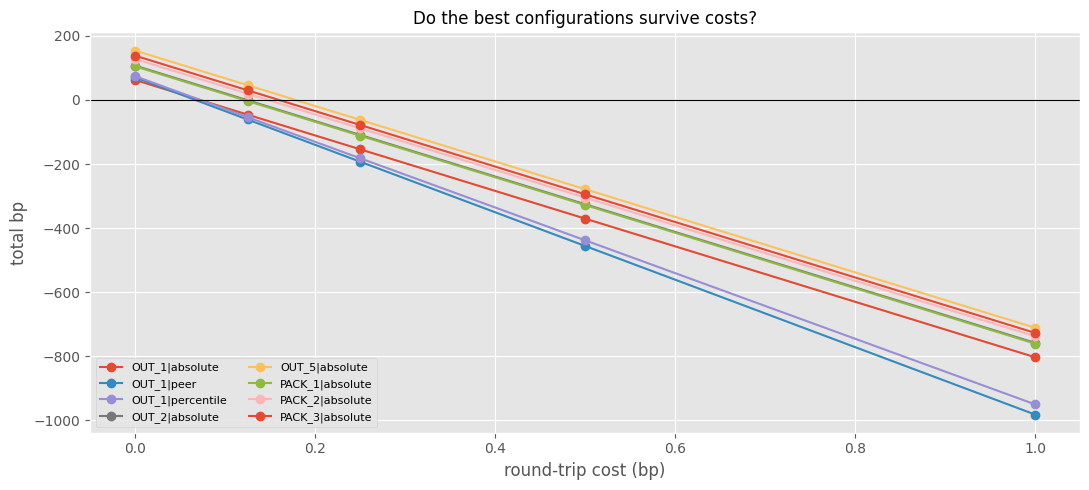

In [6]:
top = grid.sort_values("sharpe_ann", ascending=False).head(8)
rows = []
for cost in [0.0, 0.125, 0.25, 0.5, 1.0]:
    for _, r in top.iterrows():
        ret = r["_returns"] - cost
        sd = ret.std(ddof=1)
        rows.append({
            "cost_bp": cost, "config": f"{r['structure']}|{r['bucket_mode']}",
            "avg_bp": ret.mean(),
            "sharpe": (ret.mean() / sd * np.sqrt(len(ret) / max(
                (r['trades'] / max(r['trades'], 1)), 1))) if sd > 0 else 0.0,
            "total_bp": ret.sum(),
        })
cost_df = pd.DataFrame(rows).pivot(index="cost_bp", columns="config", values="total_bp")
display(cost_df.round(1))

fig, ax = plt.subplots(figsize=(11, 5))
cost_df.plot(ax=ax, marker="o")
ax.axhline(0, color="k", lw=.8); ax.set_ylabel("total bp"); ax.set_xlabel("round-trip cost (bp)")
ax.set_title("Do the best configurations survive costs?")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

## 5. Per-leg contribution of the best configuration

In [7]:
best = grid.sort_values("sharpe_ann", ascending=False).iloc[0]
st = next(s for s in structures if s.name == best["structure"])
blob = store[best["bucket_mode"]]
print(f"best by Sharpe: {best['structure']} / {best['bucket_mode']}  "
      f"SR={best['sharpe_ann']:.2f}  DSR={best['dsr']:.3f}  n={int(best['trades'])}")

rows = []
for bank, panel in blob["panels"].items():
    m = blob["metas"][bank]
    d = GRID.structure_pnl_bp(panel, st)
    if d.empty:
        continue
    j = m.join(d.rename("d"), how="inner").dropna(subset=["d"])
    if j.empty:
        continue
    pnl = j["side_rate"] * j["d"] / (st.gross or 1.0)
    rows.append({"bank": bank, "trades": len(pnl), "total_bp": pnl.sum(),
                 "avg_bp": pnl.mean(), "hit": float((pnl > 0).mean())})
display(pd.DataFrame(rows).set_index("bank").round(4))

print("\nby timestamp provenance (does the signal live in the REAL timings?):")
rows = []
for bank, panel in blob["panels"].items():
    m = blob["metas"][bank]; d = GRID.structure_pnl_bp(panel, st)
    if d.empty: continue
    j = m.join(d.rename("d"), how="inner").dropna(subset=["d"])
    j["pnl"] = j["side_rate"] * j["d"] / (st.gross or 1.0)
    for src, sub in j.groupby("timestamp_source"):
        rows.append({"bank": bank, "src": src, "n": len(sub),
                     "total_bp": sub["pnl"].sum(), "avg_bp": sub["pnl"].mean()})
prov = pd.DataFrame(rows)
display(prov.groupby("src")[["n", "total_bp", "avg_bp"]].sum().round(3) if len(prov) else "n/a")

best by Sharpe: OUT_2 / absolute  SR=0.74  DSR=0.398  n=865


,trades,total_bp,avg_bp,hit
bank,,,,
FED,398,82.5000,0.2073,0.4648
ECB,256,36.0000,0.1406,0.4844
BOE,143,-30.0000,-0.2098,0.4126
BOJ,9,2.1823,0.2425,0.7778
BOC,40,10.0000,0.2500,0.4250
SNB,19,6.5000,0.3421,0.5263



by timestamp provenance (does the signal live in the REAL timings?):


,n,total_bp,avg_bp
src,,,
forexfactory,615,67.005,0.491
synthetic,250,40.178,1.903


## 6. Verdict

Read in this order:

1. **How many configurations cleared DSR > 0.95?** If none, the grid found nothing that survives
   the cost of having searched — the top Sharpe is what this many trials produces from noise.
2. **Does the best configuration survive costs?** Break-even round-trip is `avg_bp`; the listed
   SR3 outright is roughly a quarter-tick, and the ESTR/SONIA/CORRA/SARON strips are wider.
3. **Where does the P&L come from?** If it is concentrated in synthetic-timestamp events, the
   result is about holding a session on a speech day, not about the speech.
4. **Is the outright rank profile monotone?** If Sharpe rises steadily with contract rank, that is
   duration exposure, not a speech effect.

In [8]:
summary = {
    "configs": int(len(grid)),
    "trials_priced_in": int(N_TRIALS),
    "sr_star_per_trade": float(grid["sr_star"].iloc[0]),
    "best_sharpe": float(grid["sharpe_ann"].max()),
    "best_dsr": float(grid["dsr"].max()),
    "alive_dsr_gt_95": int(((grid["dsr"] > 0.95) & (grid["trades"] >= 50)).sum()),
}
for k, v in summary.items():
    print(f"  {k:22s} {v}")

grid.drop(columns=["_returns"]).to_csv(CACHE / "grid_results.csv", index=False)
print(f"\nwrote {CACHE / 'grid_results.csv'}")

  configs                66
  trials_priced_in       1056
  sr_star_per_trade      0.053976484179675044
  best_sharpe            0.741131331754679
  best_dsr               0.39780537259313253
  alive_dsr_gt_95        0

wrote C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\intraday_fed_hawk_dove\_global_cache\grid_results.csv
